In [3]:
import subprocess
import sys

subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', 'imbalanced-learn'])

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


0

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (roc_auc_score, precision_recall_curve, 
                             average_precision_score, classification_report,
                             confusion_matrix)
from sklearn.pipeline import Pipeline
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('Train-1542865627584.csv')
beneficiary = pd.read_csv('Train_Beneficiarydata-1542865627584.csv')
inpatient = pd.read_csv('Train_Inpatientdata-1542865627584.csv')
outpatient = pd.read_csv('Train_Outpatientdata-1542865627584.csv')

print(f"Provider records: {len(train)}")
print(f"Fraud rate: {train['PotentialFraud'].map({'Yes':1,'No':0}).mean():.2%}")
print(f"Beneficiary records: {len(beneficiary)}")
print(f"Inpatient claims: {len(inpatient)}")
print(f"Outpatient claims: {len(outpatient)}")

Matplotlib is building the font cache; this may take a moment.


Provider records: 5410
Fraud rate: 9.35%
Beneficiary records: 138556
Inpatient claims: 40474
Outpatient claims: 517737


In [2]:
def engineer_provider_features(inpatient, outpatient, beneficiary):
    """
    Engineer fraud detection features at the provider level.
    Key insight: fraud shows up in billing PATTERNS not individual claims.
    """
    
    # Combine inpatient and outpatient claims
    inpatient['ClaimType'] = 'Inpatient'
    outpatient['ClaimType'] = 'Outpatient'
    
    # Standardize column names
    common_cols = ['Provider', 'BeneID', 'ClaimID', 'ClaimStartDt', 
                   'ClaimEndDt', 'InscClaimAmtReimbursed', 'AttendingPhysician',
                   'ClaimType']
    
    all_claims = pd.concat([
        inpatient[common_cols + ['AdmissionDt', 'DischargeDt']],
        outpatient[common_cols]
    ], ignore_index=True)
    
    # Provider-level aggregations — fraud shows in aggregate patterns
    provider_features = all_claims.groupby('Provider').agg(
        total_claims=('ClaimID', 'count'),
        total_reimbursed=('InscClaimAmtReimbursed', 'sum'),
        avg_claim_amount=('InscClaimAmtReimbursed', 'mean'),
        max_claim_amount=('InscClaimAmtReimbursed', 'max'),
        unique_patients=('BeneID', 'nunique'),
        unique_physicians=('AttendingPhysician', 'nunique'),
        claims_per_patient=('ClaimID', lambda x: len(x) / all_claims.loc[x.index, 'BeneID'].nunique()),
        inpatient_ratio=('ClaimType', lambda x: (x == 'Inpatient').mean()),
    ).reset_index()
    
    # Claims per physician — high ratio signals possible fraud ring
    provider_features['claims_per_physician'] = (
        provider_features['total_claims'] / 
        provider_features['unique_physicians'].clip(lower=1)
    )
    
    # Revenue concentration — fraud providers often bill maximum amounts
    provider_features['revenue_concentration'] = (
        provider_features['max_claim_amount'] / 
        provider_features['avg_claim_amount'].clip(lower=1)
    )
    
    return provider_features

provider_features = engineer_provider_features(inpatient, outpatient, beneficiary)
print(f"Provider features shape: {provider_features.shape}")
print(provider_features.head())

Provider features shape: (5410, 11)
   Provider  total_claims  total_reimbursed  avg_claim_amount  \
0  PRV51001            25            104640       4185.600000   
1  PRV51003           132            605670       4588.409091   
2  PRV51004           149             52170        350.134228   
3  PRV51005          1165            280910        241.124464   
4  PRV51007            72             33710        468.194444   

   max_claim_amount  unique_patients  unique_physicians  claims_per_patient  \
0             42000               24                 14            1.041667   
1             57000              117                 44            1.128205   
2              3300              138                 38            1.079710   
3              4080              495                  6            2.353535   
4             10000               58                 10            1.241379   

   inpatient_ratio  claims_per_physician  revenue_concentration  
0         0.200000              

In [3]:
# Merge features with fraud labels
provider_features['PotentialFraud'] = (
    provider_features['Provider']
    .map(train.set_index('Provider')['PotentialFraud'])
    .map({'Yes': 1, 'No': 0})
)

# Features and target
feature_cols = [c for c in provider_features.columns 
                if c not in ['Provider', 'PotentialFraud']]

X = provider_features[feature_cols].fillna(0)
y = provider_features['PotentialFraud']

print(f"Class balance: {y.mean():.2%} fraud rate")

# Train test split — stratified to preserve fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"After SMOTE: {y_train_resampled.mean():.2%} fraud rate in training set")

# Baseline: Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train_resampled)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])
lr_ap = average_precision_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])
print(f"Logistic Regression — AUC-ROC: {lr_auc:.3f} | Average Precision: {lr_ap:.3f}")

# Production model: XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='aucpr',
    early_stopping_rounds=20,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_probs)
xgb_ap = average_precision_score(y_test, xgb_probs)
print(f"XGBoost — AUC-ROC: {xgb_auc:.3f} | Average Precision: {xgb_ap:.3f}")

Class balance: 9.35% fraud rate
After SMOTE: 50.00% fraud rate in training set
Logistic Regression — AUC-ROC: 0.953 | Average Precision: 0.739
XGBoost — AUC-ROC: 0.950 | Average Precision: 0.694


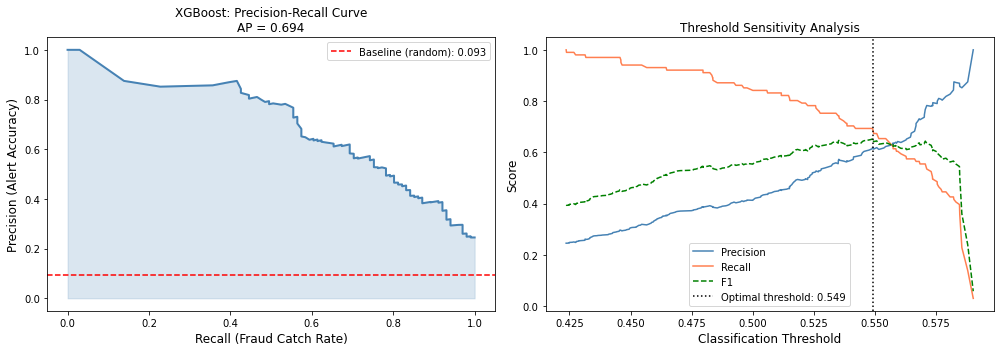


Optimal operating threshold: 0.549
At this threshold:
              precision    recall  f1-score   support

  Legitimate       0.97      0.96      0.96       981
       Fraud       0.62      0.69      0.65       101

    accuracy                           0.93      1082
   macro avg       0.79      0.82      0.81      1082
weighted avg       0.94      0.93      0.93      1082



In [4]:
def plot_precision_recall_with_threshold(y_test, probs, model_name):
    """
    For fraud detection, this plot matters more than ROC.
    Shows the real operational tradeoff:
    - High precision = fewer false alarms (auditors waste less time)
    - High recall = catch more actual fraud (less money lost)
    """
    precision, recall, thresholds = precision_recall_curve(y_test, probs)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Precision-Recall curve
    axes[0].plot(recall, precision, linewidth=2, color='steelblue')
    axes[0].fill_between(recall, precision, alpha=0.2, color='steelblue')
    axes[0].set_xlabel('Recall (Fraud Catch Rate)', fontsize=12)
    axes[0].set_ylabel('Precision (Alert Accuracy)', fontsize=12)
    axes[0].set_title(f'{model_name}: Precision-Recall Curve\nAP = {average_precision_score(y_test, probs):.3f}', fontsize=12)
    axes[0].axhline(y=y_test.mean(), color='red', linestyle='--', 
                    label=f'Baseline (random): {y_test.mean():.3f}')
    axes[0].legend()
    
    # Threshold analysis — the operational decision
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
    optimal_threshold = thresholds[np.argmax(f1_scores)]
    
    axes[1].plot(thresholds, precision[:-1], label='Precision', color='steelblue')
    axes[1].plot(thresholds, recall[:-1], label='Recall', color='coral')
    axes[1].plot(thresholds, f1_scores, label='F1', color='green', linestyle='--')
    axes[1].axvline(x=optimal_threshold, color='black', linestyle=':', 
                    label=f'Optimal threshold: {optimal_threshold:.3f}')
    axes[1].set_xlabel('Classification Threshold', fontsize=12)
    axes[1].set_ylabel('Score', fontsize=12)
    axes[1].set_title('Threshold Sensitivity Analysis', fontsize=12)
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig('precision_recall_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return optimal_threshold

optimal_threshold = plot_precision_recall_with_threshold(y_test, xgb_probs, "XGBoost")
print(f"\nOptimal operating threshold: {optimal_threshold:.3f}")
print(f"At this threshold:")
preds_at_threshold = (xgb_probs >= optimal_threshold).astype(int)
print(classification_report(y_test, preds_at_threshold, 
                            target_names=['Legitimate', 'Fraud']))

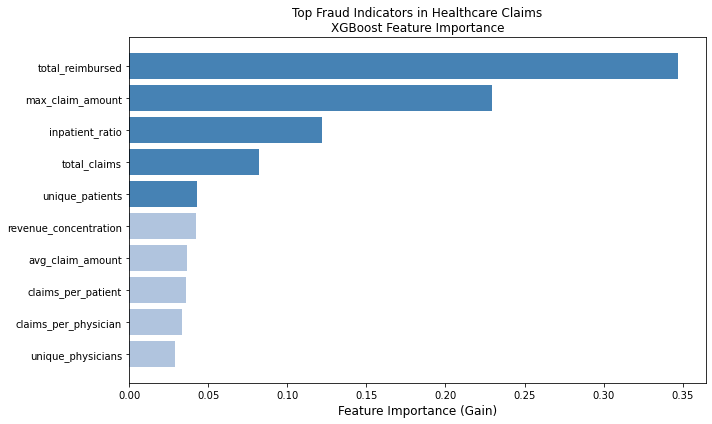


Top 5 fraud indicators:
         feature  importance
total_reimbursed    0.347109
max_claim_amount    0.229655
 inpatient_ratio    0.121934
    total_claims    0.082151
 unique_patients    0.043064


In [5]:
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if i < 5 else 'lightsteelblue' 
          for i in range(len(feature_importance))]
plt.barh(feature_importance['feature'], 
         feature_importance['importance'],
         color=colors)
plt.xlabel('Feature Importance (Gain)', fontsize=12)
plt.title('Top Fraud Indicators in Healthcare Claims\nXGBoost Feature Importance', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 fraud indicators:")
print(feature_importance.head(5).to_string(index=False))
